# Electric Vehicle Sales Analysis and Prediction in India

This project analyzes EV sales data across Indian states and
builds a machine learning model to predict EV sales quantity.

Tools Used:
- Python
- Pandas
- Numpy
- Seaborn
- Scikit-learn
- SQL

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [17]:
df = pd.read_csv("C:/Users/admin/Desktop/EV_Sales_India_Project/EV_Dataset.csv")

df.head()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0


### Dataset Overview

In [18]:
df.shape

(96845, 8)

In [19]:
df.columns

Index(['Year', 'Month_Name', 'Date', 'State', 'Vehicle_Class',
       'Vehicle_Category', 'Vehicle_Type', 'EV_Sales_Quantity'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


In [21]:
df.describe()

,Year,EV_Sales_Quantity
count,96845.000000,96845.000000
mean,2018.622768,37.108896
std,2.895581,431.566675
min,2014.000000,0.000000
25%,2016.000000,0.000000
50%,2019.000000,0.000000
75%,2021.000000,0.000000
max,2024.000000,20584.000000


In [22]:
df.isnull().sum()

Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64

### Data Cleaning

df['Year'] = df['Year'].astype(int)

In [24]:
df['Date'] = pd.to_datetime(df['Date'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Year               96845 non-null  int64         
 1   Month_Name         96845 non-null  object        
 2   Date               96845 non-null  datetime64[ns]
 3   State              96845 non-null  object        
 4   Vehicle_Class      96845 non-null  object        
 5   Vehicle_Category   96845 non-null  object        
 6   Vehicle_Type       96845 non-null  object        
 7   EV_Sales_Quantity  96845 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 5.9+ MB


In [26]:
df.duplicated().sum()

np.int64(0)

In [28]:
state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False)

state_sales.head(10)

State
Uttar Pradesh    732074.0
Maharashtra      401535.0
Karnataka        315498.0
Delhi            268538.0
Rajasthan        228573.0
Bihar            213465.0
Tamil Nadu       206902.0
Gujarat          176713.0
Assam            151917.0
Kerala           133246.0
Name: EV_Sales_Quantity, dtype: float64

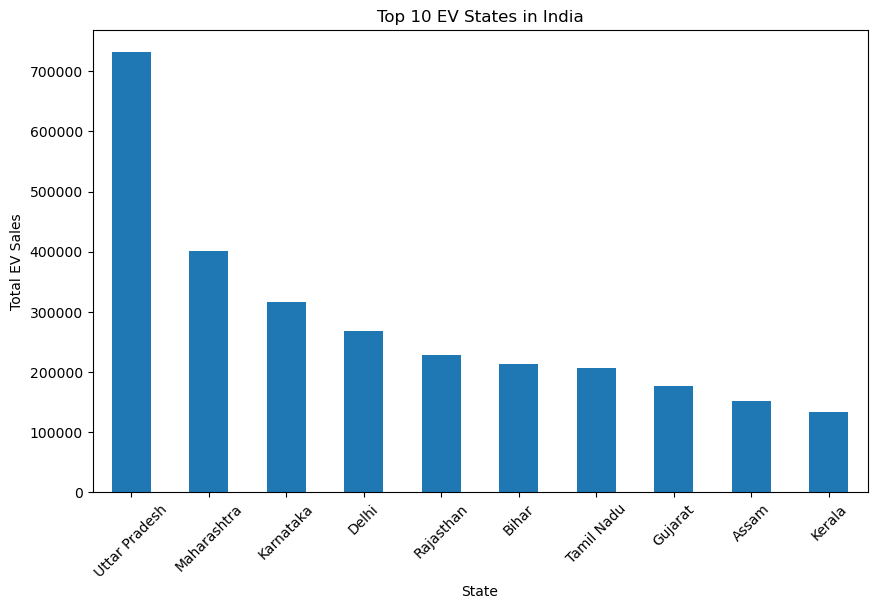

In [29]:
plt.figure(figsize=(10,6))

state_sales.head(10).plot(kind='bar')

plt.title("Top 10 EV States in India")

plt.xlabel("State")

plt.ylabel("Total EV Sales")

plt.xticks(rotation=45)

plt.show()

### Insight

EV sales distribution varies significantly across states.
States with better EV infrastructure and urbanization
show higher EV adoption.

In [32]:
category_sales = df.groupby('Vehicle_Category')['EV_Sales_Quantity'].sum()

category_sales

Vehicle_Category
2-Wheelers    1808105.0
3-Wheelers    1620310.0
4-Wheelers     149775.0
Bus              7009.0
Others           8612.0
Name: EV_Sales_Quantity, dtype: float64

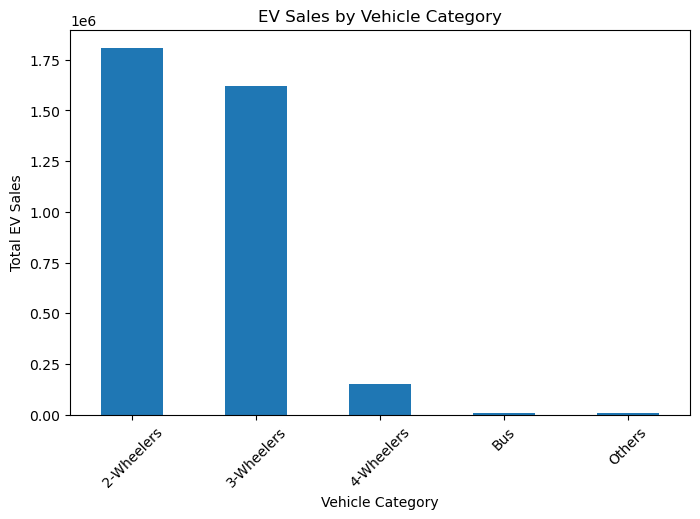

In [33]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("EV Sales by Vehicle Category")

plt.xlabel("Vehicle Category")

plt.ylabel("Total EV Sales")

plt.xticks(rotation=45)

plt.show()

In [34]:
year_sales = df.groupby('Year')['EV_Sales_Quantity'].sum()

year_sales

Year
2014       2392.0
2015       7805.0
2016      49855.0
2017      87420.0
2018     130254.0
2019     166819.0
2020     124684.0
2021     331498.0
2022    1024723.0
2023    1525179.0
2024     143182.0
Name: EV_Sales_Quantity, dtype: float64

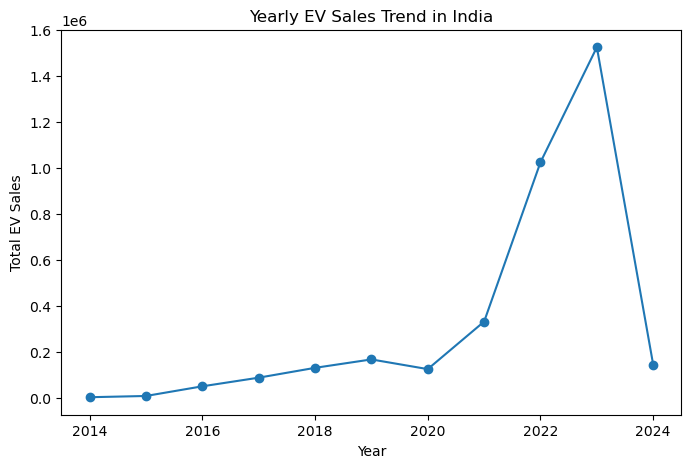

In [35]:
plt.figure(figsize=(8,5))

year_sales.plot(kind='line', marker='o')

plt.title("Yearly EV Sales Trend in India")

plt.xlabel("Year")

plt.ylabel("Total EV Sales")

plt.show()

In [36]:
type_sales = df.groupby('Vehicle_Type')['EV_Sales_Quantity'].sum().sort_values(ascending=False)

type_sales.head(10)

Vehicle_Type
2W_Personal           1796340.0
3W_Shared_LowSpeed    1408127.0
4W_Personal            130676.0
3W_Goods_LowSpeed       90656.0
3W_Shared               76132.0
3W_Goods                44974.0
4W_Shared               19099.0
2W_Shared               11765.0
Others                   8612.0
Bus                      7009.0
Name: EV_Sales_Quantity, dtype: float64

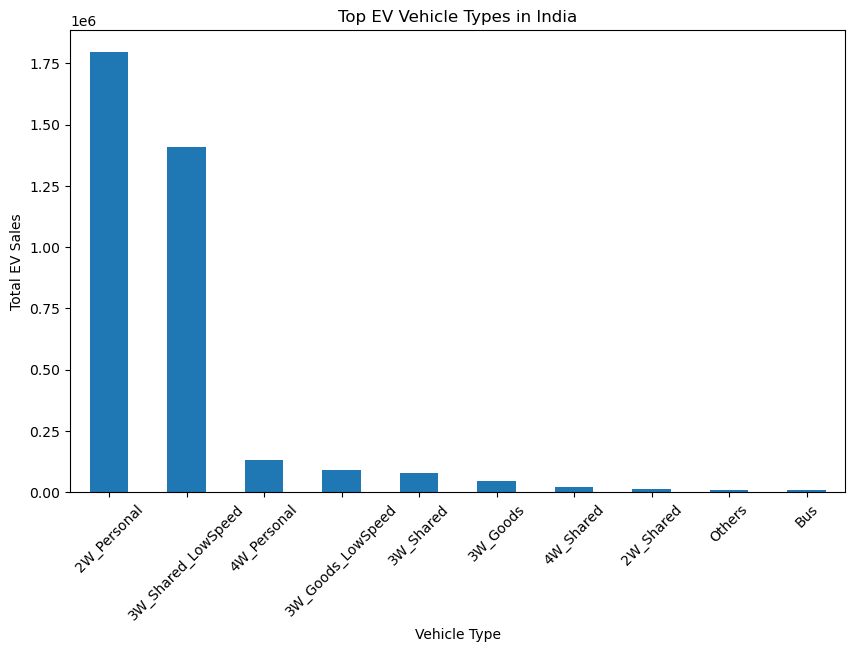

In [37]:
plt.figure(figsize=(10,6))

type_sales.head(10).plot(kind='bar')

plt.title("Top EV Vehicle Types in India")

plt.xlabel("Vehicle Type")

plt.ylabel("Total EV Sales")

plt.xticks(rotation=45)

plt.show()

## SQL-Based Data Analysis
Using SQL queries to explore EV sales patterns.

In [38]:
import sqlite3

In [39]:
conn = sqlite3.connect("ev_sales.db")

In [40]:
df.to_sql("ev_sales", conn, if_exists="replace", index=False)

96845

In [41]:
query = """
SELECT SUM(EV_Sales_Quantity) as Total_EV_Sales
FROM ev_sales
"""

pd.read_sql(query, conn)

,Total_EV_Sales
0,3593811.0


In [42]:
query = """
SELECT State, SUM(EV_Sales_Quantity) as Total_Sales
FROM ev_sales
GROUP BY State
ORDER BY Total_Sales DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,State,Total_Sales
0,Uttar Pradesh,732074.0
1,Maharashtra,401535.0
2,Karnataka,315498.0
3,Delhi,268538.0
4,Rajasthan,228573.0
5,Bihar,213465.0
6,Tamil Nadu,206902.0
7,Gujarat,176713.0
8,Assam,151917.0
9,Kerala,133246.0


### Insight

SQL analysis shows that a few states contribute a large share
of EV sales in India. These states likely have better EV
infrastructure and higher urban adoption.

In [43]:
query = """
SELECT Vehicle_Category,
SUM(EV_Sales_Quantity) as Sales
FROM ev_sales
GROUP BY Vehicle_Category
ORDER BY Sales DESC
"""

pd.read_sql(query, conn)

,Vehicle_Category,Sales
0,2-Wheelers,1808105.0
1,3-Wheelers,1620310.0
2,4-Wheelers,149775.0
3,Others,8612.0
4,Bus,7009.0


### Insight

SQL results indicate that two-wheelers and three-wheelers
dominate the EV market in India, suggesting that affordable
electric mobility segments are growing faster.

In [44]:
query = """
SELECT Year,
SUM(EV_Sales_Quantity) as Total_Sales
FROM ev_sales
GROUP BY Year
ORDER BY Year
"""

pd.read_sql(query, conn)

,Year,Total_Sales
0,2014,2392.0
1,2015,7805.0
2,2016,49855.0
3,2017,87420.0
4,2018,130254.0
5,2019,166819.0
6,2020,124684.0
7,2021,331498.0
8,2022,1024723.0
9,2023,1525179.0


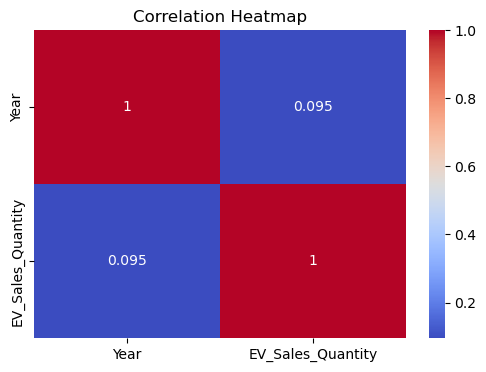

In [45]:
plt.figure(figsize=(6,4))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

## EV sales prediction using machine learning

In [46]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [55]:
df_ml = df.drop(columns=['Month_Name', 'Date'])

In [56]:
df_encoded = pd.get_dummies(df_ml, columns=['State','Vehicle_Class','Vehicle_Category','Vehicle_Type'])

In [57]:
X = df_encoded.drop('EV_Sales_Quantity', axis=1)
y = df_encoded['EV_Sales_Quantity']

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [59]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
pred = model.predict(X_test)

In [63]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("RMSE:", rmse)

RMSE: 128.96086383663874


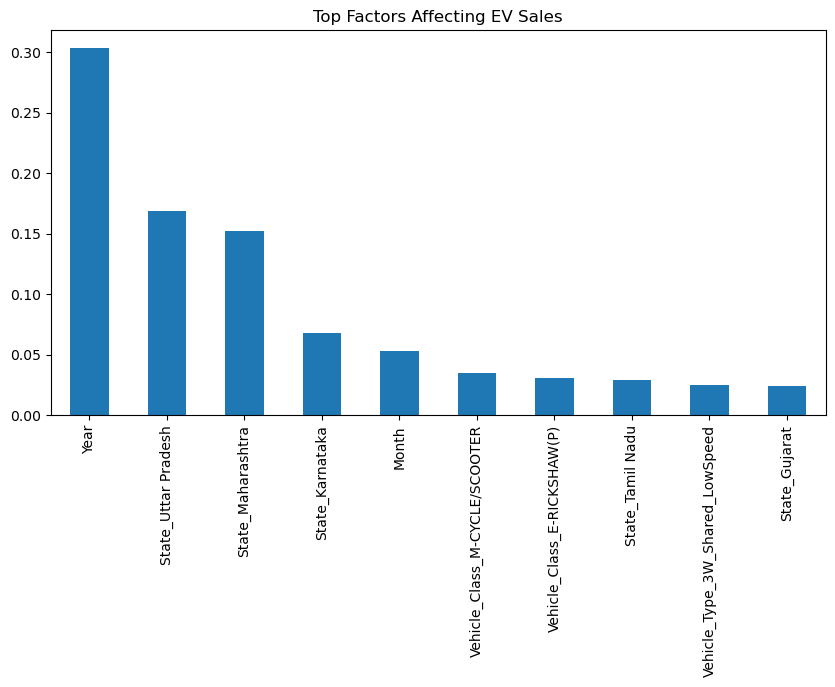

In [64]:
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.Series(importance, index=X_train.columns)

top_features = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_features.plot(kind='bar')

plt.title("Top Factors Affecting EV Sales")

plt.show()

In [67]:
y_pred = model.predict(X_test)

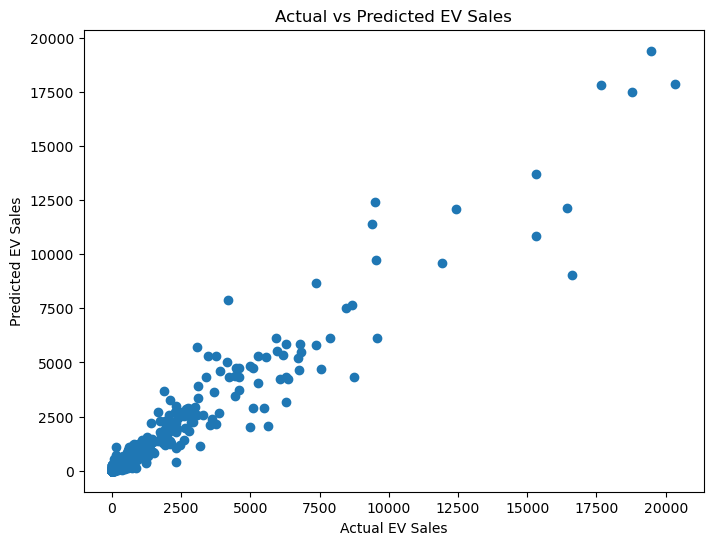

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual EV Sales")
plt.ylabel("Predicted EV Sales")
plt.title("Actual vs Predicted EV Sales")
plt.show()

### Insight

The scatter plot compares actual EV sales with
predicted sales from the model.

Most points are clustered near the diagonal region,
indicating that the model predictions are reasonably
close to the actual values.

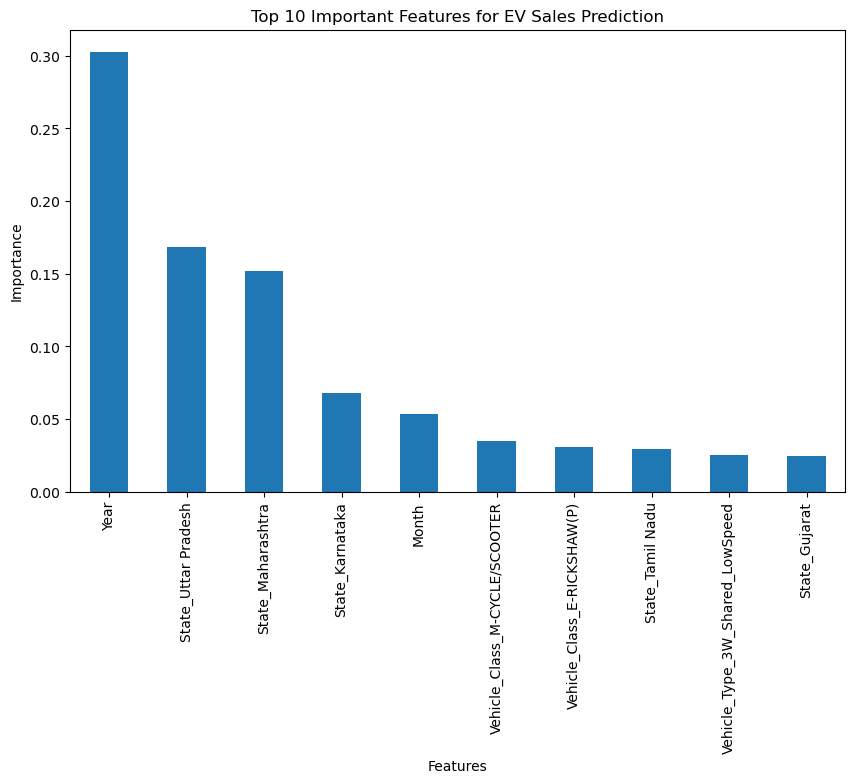

In [69]:
importance = model.feature_importances_

feature_importance = pd.Series(importance,index=X_train.columns).sort_values(ascending=False)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features for EV Sales Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

### Insight

Feature importance analysis shows which variables
have the highest impact on EV sales prediction.

Factors such as State, Vehicle Category, and
Vehicle Type play a major role in determining
EV sales patterns.

Feature importance analysis shows that state, vehicle category,
and vehicle type significantly influence EV sales in India.
Random Forest model helps identify key factors affecting EV adoption.

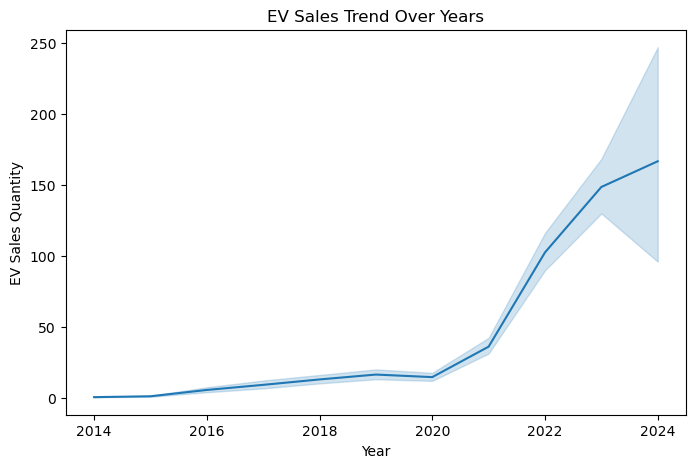

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.lineplot(x='Year', y='EV_Sales_Quantity', data=df)
plt.title("EV Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("EV Sales Quantity")
plt.show()

### Insight

The graph shows the trend of EV sales over the years in India.
EV adoption has gradually increased, indicating growing
interest and infrastructure for electric mobility.

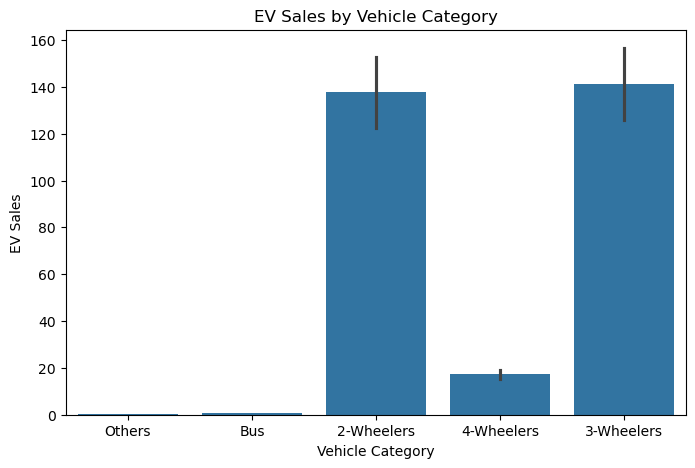

In [71]:
plt.figure(figsize=(8,5))
sns.barplot(x='Vehicle_Category', y='EV_Sales_Quantity', data=df)
plt.title("EV Sales by Vehicle Category")
plt.xlabel("Vehicle Category")
plt.ylabel("EV Sales")
plt.show()

### Insight

The bar chart shows that certain vehicle categories
contribute more to EV sales. Two-wheelers and
three-wheelers are major contributors to EV adoption
in India compared to other categories.

## Final Conclusion

This project analyzed EV sales data in India using
both SQL-based analysis and machine learning techniques.

SQL queries were used to explore key patterns such as
state-wise EV adoption and vehicle category trends.

Exploratory analysis showed that EV sales are increasing
over the years and that two-wheelers dominate the market.

A Random Forest regression model was trained to predict
EV sales and achieved an RMSE of approximately 129,
indicating reasonable predictive performance.

Overall, the analysis highlights the growing adoption
of electric vehicles and the importance of regional
and vehicle-category factors in EV sales.